## Implémentation de l'architecture UNet

Si besoin, il est possible d'installer les librairies nécessaires en entrant les commandes suivantes dans un terminal :

    pip install os
    pip install torch
    pip install torchvision
    pip install torch_directml

In [ ]:
#Importation des librairies utilisées par la suite

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import roc_curve, auc

#######################################################################################################

try:
    import torch_directml
except ModuleNotFoundError:
    pass

try:
    device = torch_directml.device() if torch_directml.is_available() else torch.device("cpu")
except NameError:
    device = torch.device("cpu")

def torch_load(path: str):
    return torch.load(path, map_location=device, weights_only=False)

In [18]:
class SegmentationDataset(Dataset): # Création d'une classe SegmentationDataset gérant l'importation et la mise en forme des images et des masques
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir)) # Permet de faire correspondre les indices des images et masques correspondants
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.masks[index])

        image = Image.open(img_path).convert("L") # On convertit l'image en échelle de gris
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0).float() 

        return image, mask
    
transform = transforms.Compose([
    transforms.Resize((128, 128)), # Redimensionnement à 128x128 px pour respecter les dimensions d'entrée du modèle UNet
    transforms.ToTensor(), # Conversion en tenseur PyTorch
    transforms.Normalize(mean=[0.5], std=[0.5]) # Normalisation pour accélérer et stabiliser l'entraînement
])

In [19]:
# Chargement des datasets d'entraînement et de test

train_image_dir = "data/train/images"
train_mask_dir = "data/train/masks"

test_image_dir = "data/train/images"
test_mask_dir = "data/train/masks"

full_dataset = SegmentationDataset(train_image_dir, train_mask_dir, transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

test_dataset = SegmentationDataset(test_image_dir, test_mask_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
# Définition du layer de double convolution

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# Définition des layers "down" utilisés lors de la phase d'encodage du modèle

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.model(x)

# Définition des layers "up" utilisés lors de la phase de décodage du modèle

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels * 2, out_channels) 

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

# Définition du modèle UNet

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1 = DoubleConv(1, 16)
        self.p1 = Down(16, 32)
        self.p2 = Down(32, 64)
        self.p3 = Down(64, 128)
        self.p4 = Down(128, 256)

        self.u1 = Up(256, 128)
        self.u2 = Up(128, 64)
        self.u3 = Up(64, 32)
        self.u4 = Up(32, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        c1 = self.c1(x)
        c2 = self.p1(c1)
        c3 = self.p2(c2)
        c4 = self.p3(c3)
        c5 = self.p4(c4)

        u1 = self.u1(c5, c4)
        u2 = self.u2(u1, c3)
        u3 = self.u3(u2, c2)
        u4 = self.u4(u3, c1)

        return self.out(u4)

Modèle importé


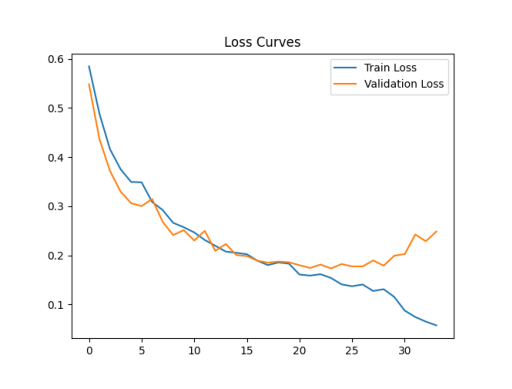

In [ ]:
model = UNet().to(device)

try:
    model.load_state_dict(torch_load("modeles_entraines/model_base.pth"))
    print("Modèle importé")
    img = plt.imread("loss_model_base.png") 
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except FileNotFoundError:
    print("Fichier manquant")
    print("Lancement de l'entraînement...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    num_epochs = 1000
    train_losses = []
    val_losses_base = []
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses_base.append(val_loss)

        scheduler.step(val_loss)
        print("Epoch :", epoch+1, "| Train :", train_loss, "| Val :", val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "modeles_entraines/model_base.pth")
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= 10:
            print("Early stopping déclenché à l'époque :", epoch+1)
            break

    notebook_dir = os.getcwd()
    os.makedirs(os.path.join(notebook_dir, "figures"), exist_ok=True)

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses_base, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curves")
    plt.savefig("loss_model_base.png")
    plt.show()

Tant que le validation loss ne remonte pas, on n'a pas de surentrainement

In [22]:
model.load_state_dict(torch_load("modeles_entraines/model_base.pth"))
model.eval()

def compute_metrics(pred, mask):
    pred = pred.view(-1)
    mask = mask.view(-1)

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-8)

    return iou.item(), dice.item()

total_iou = 0
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(images.size(0)):
            iou, dice = compute_metrics(preds[i], masks[i])
            total_iou += iou
            total_dice += dice

avg_iou = total_iou / len(test_dataset)
avg_dice = total_dice / len(test_dataset)

print("Test IoU :", avg_iou) # IoU : chevauchement entre masque prédit et masque réel (max : 1)
print("Test Dice :",avg_dice) # IoU : similarité entre les deux masques (max : 1)

image, mask = test_dataset[0]

model.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.permute(1,2,0).numpy()

Test IoU : 0.4074799104898084
Test Dice : 0.4355011519559412


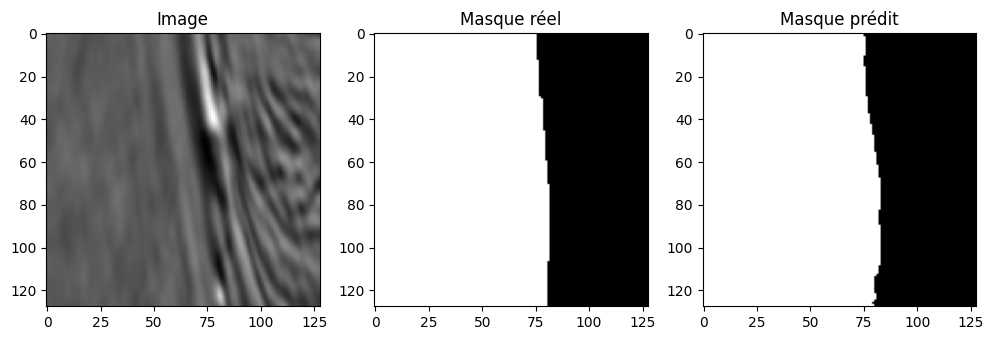

In [23]:
# Test de prédiction du modèle sur une image du dataset

image, mask = test_dataset[110]

model.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image, cmap="grey")

plt.subplot(1,3,2)
plt.title("Masque réel")
plt.imshow(mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Masque prédit")
plt.imshow(pred, cmap="gray")

plt.show()

### 5.1 Max pooling
Max pooling has been used for down-sizing the input volume. Instead of max pooling, is it possible to simply make use of convolution with a different stride, e.g., 2 ? How does it impact the performance ?


In [24]:
class DoubleConv_stride2(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, stride=2), # Convolution avec stride = 2 pour remplacer Max Pool
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),        
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class Down_stride2(nn.Module): # Modification de la classe Down 
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.model = nn.Sequential(
            DoubleConv_stride2(in_channels, out_channels)
        )

    def forward(self, x):
        return self.model(x)


class UNet_stride2(nn.Module): # Adaptation du modèle UNet
    def __init__(self):
        super().__init__()

        self.c1 = DoubleConv(1, 16)
        self.p1 = Down_stride2(16, 32)
        self.p2 = Down_stride2(32, 64)
        self.p3 = Down_stride2(64, 128)
        self.p4 = Down_stride2(128, 256)

        self.u1 = Up(256, 128)
        self.u2 = Up(128, 64)
        self.u3 = Up(64, 32)
        self.u4 = Up(32, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        c1 = self.c1(x)
        c2 = self.p1(c1)
        c3 = self.p2(c2)
        c4 = self.p3(c3)
        c5 = self.p4(c4)

        u1 = self.u1(c5, c4)
        u2 = self.u2(u1, c3)
        u3 = self.u3(u2, c2)
        u4 = self.u4(u3, c1)

        return self.out(u4)

Modèle importé


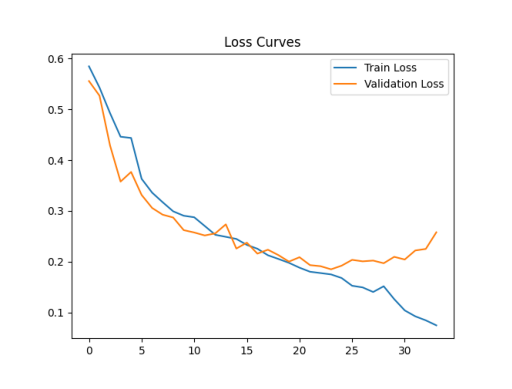

Test IoU : 0.40727021156725823
Test Dice : 0.4369632893655362


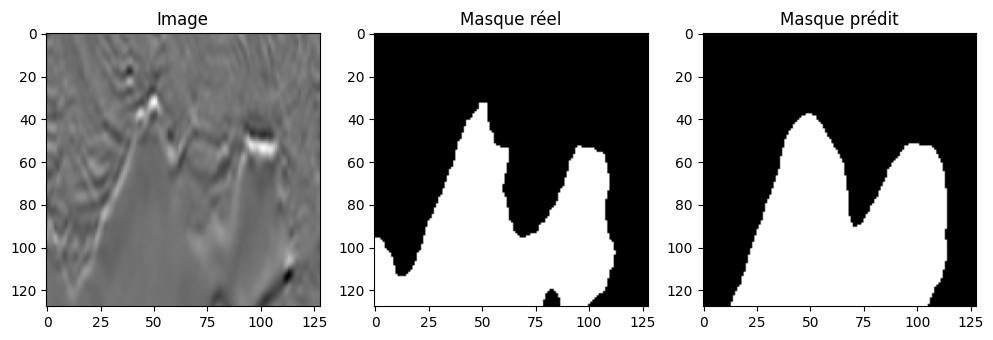

In [ ]:
# Entraînement du modèle sans Max Pool

model_stride2 = UNet_stride2().to(device)

try:
    model_stride2.load_state_dict(torch_load("modeles_entraines/model_stride2.pth"))
    print("Modèle importé")
    img = plt.imread("loss_model_stride2.png") 
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except FileNotFoundError:
    print("Fichier manquant")
    print("Lancement de l'entraînement...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_stride2.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    num_epochs = 1000
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model_stride2.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model_stride2(images)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model_stride2.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model_stride2(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step(val_loss)
        print("Epoch :", epoch+1, "| Train :", train_loss, "| Val :", val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model_stride2.state_dict(), "modeles_entraines/model_stride2.pth")
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= 10:
            print("Early stopping déclenché à l'époque :", epoch+1)
            break

    notebook_dir = os.getcwd()
    os.makedirs(os.path.join(notebook_dir, "figures"), exist_ok=True)

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curves")
    plt.savefig("loss_model_stride2.png")
    plt.show()

model_stride2.load_state_dict(torch_load("modeles_entraines/model_stride2.pth"))
model_stride2.eval()

def compute_metrics(pred, mask):
    pred = pred.view(-1)
    mask = mask.view(-1)

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-8)

    return iou.item(), dice.item()

total_iou = 0
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model_stride2(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(images.size(0)):
            iou, dice = compute_metrics(preds[i], masks[i])
            total_iou += iou
            total_dice += dice

avg_iou = total_iou / len(test_dataset)
avg_dice = total_dice / len(test_dataset)

print("Test IoU :", avg_iou)
print("Test Dice :",avg_dice)

image, mask = test_dataset[0]

model_stride2.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model_stride2(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.permute(1,2,0).numpy()

image, mask = test_dataset[250]

model_stride2.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model_stride2(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image, cmap="grey")

plt.subplot(1,3,2)
plt.title("Masque réel")
plt.imshow(mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Masque prédit")
plt.imshow(pred, cmap="gray")

plt.show()

Max pooling : réduction de la résolution spatiale (ici par 2) en appliquant un filtre conservant le maximum de chaque zone

Cela permet de réduire le nombre de calculs nécessaires pour les couches suivantes

La différence est que la convolution apprend à réduire la dimension tandis que le Maxpool applique une règle mathématique -> cela rend en théorie l'entraînement plus lent et rend le réseau plus lourd en paramètres. On remarque également qu'elle est beaucoup plus susceptible au surapprentissage que le Maxpool.

Ici, puisque nous avons des images en échelle de gris, l'utilisation de Maxpool paraît plus intéressante


### 5.2 Skip Connections
The skip connections have been used in the proposed architecture. Why is this important ? Suppose that we remove these skip connections from the proposed architecture, how does it impact the result ? Please explain your intuition. Furthermore, the current skip connections consist of concatenating feature maps of the encoder with those of the decoder at the same level, is it possible to make use of other alternatives, for instance addition, Max or Min operation ? Do they impact the results ? Explain.


Le problème d'Unet est que les informations sont très compressées (8x8x256) ce qui entraîne une grande perte d'information lors de la remontée. Les skips connections transmettent directement les images en haute résolution au décodeur.

Cela permet d'éviter que les contours soient flous, que les petites informations soient effacées par la compression

Il est possible d'utiliser plusieurs alternatives :
- Utiliser l'addition : on fusionne les deux images directement. La principale limitation de cette méthode est que l'on ne fait pas de choix, donc le résultat peut être plus flou et plus bruité;
- Utiliser le max : on garde les activations les plus fortes. Le principal problème de cette méthode est que l'on écrase les activations faibles, contenant parfois des informations importantes.
- Utiliser le min : on garde les informations les plus faibles. Cette méthode n'est pas très pertinent puisque l'on transmet alors très peu d'information utile



In [27]:
class UNet_noSkip(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1 = DoubleConv(1, 16)
        self.p1 = Down(16, 32)
        self.p2 = Down(32, 64)
        self.p3 = Down(64, 128)
        self.p4 = Down(128, 256)

        self.u1 = nn.ConvTranspose2d(256, 128, 2, stride=2) # La remontée se fait sans skip connexions
        self.c6 = DoubleConv(128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.c7 = DoubleConv(64, 64)

        self.u3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.c8 = DoubleConv(32, 32)

        self.u4 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.c9 = DoubleConv(16, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        c1 = self.c1(x)
        c2 = self.p1(c1)
        c3 = self.p2(c2)
        c4 = self.p3(c3)
        c5 = self.p4(c4)

        u1 = self.c6(self.u1(c5))
        u2 = self.c7(self.u2(u1))
        u3 = self.c8(self.u3(u2))
        u4 = self.c9(self.u4(u3))

        return self.out(u4)

Modèle importé


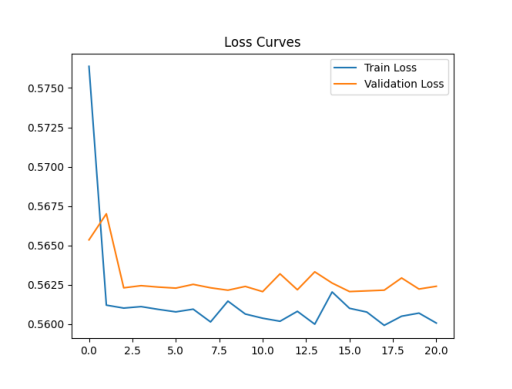

Test IoU : 0.0
Test Dice : 0.0


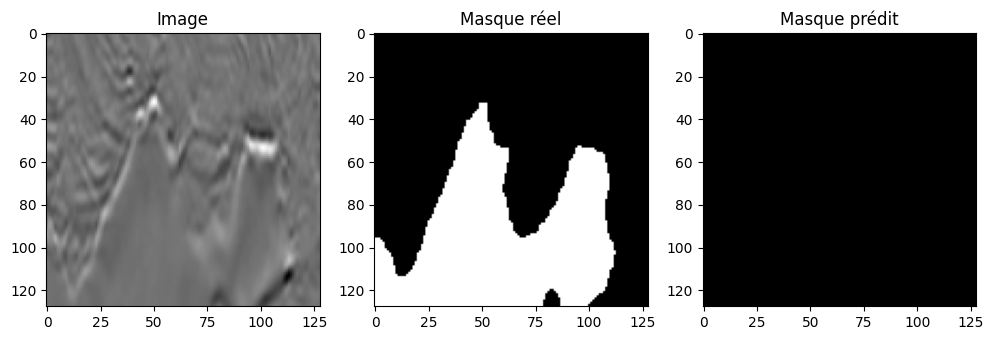

In [ ]:
# Entraînement du modèle sans skip connexions

model_noskipcon = UNet_noSkip().to(device)

try:
    model_noskipcon.load_state_dict(torch_load("modeles_entraines/model_noskipcon.pth"))
    print("Modèle importé")
    img = plt.imread("loss_model_noskipcon.png") 
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except FileNotFoundError:
    print("Fichier manquant")
    print("Lancement de l'entraînement...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_noskipcon.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    num_epochs = 1000
    train_losses = []
    val_losses_noskip = []
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model_noskipcon.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model_noskipcon(images)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model_noskipcon.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model_noskipcon(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses_noskip.append(val_loss)

        scheduler.step(val_loss)
        print("Epoch :", epoch+1, "| Train :", train_loss, "| Val :", val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model_noskipcon.state_dict(), "modeles_entraines/model_noskipcon.pth")
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= 10:
            print("Early stopping déclenché à l'époque :", epoch+1)
            break

    notebook_dir = os.getcwd()
    os.makedirs(os.path.join(notebook_dir, "figures"), exist_ok=True)

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses_noskip, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curves")
    plt.savefig("loss_model_noskipcon.png")
    plt.show()

model_noskipcon.load_state_dict(torch_load("modeles_entraines/model_noskipcon.pth"))
model_noskipcon.eval()

def compute_metrics(pred, mask):
    pred = pred.view(-1)
    mask = mask.view(-1)

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-8)

    return iou.item(), dice.item()

total_iou = 0
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model_noskipcon(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(images.size(0)):
            iou, dice = compute_metrics(preds[i], masks[i])
            total_iou += iou
            total_dice += dice

avg_iou = total_iou / len(test_dataset)
avg_dice = total_dice / len(test_dataset)

print("Test IoU :",avg_iou)
print("Test Dice :", avg_dice)

image, mask = test_dataset[0]

model_noskipcon.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model_noskipcon(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.permute(1,2,0).numpy()

image, mask = test_dataset[250]

model_noskipcon.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model_noskipcon(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image, cmap="grey")

plt.subplot(1,3,2)
plt.title("Masque réel")
plt.imshow(mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Masque prédit")
plt.imshow(pred, cmap="gray")

plt.show()

On remarque que l'apprentissage est bien moins bon

In [29]:
class Up_Add(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = x1 + x2          # Etape d'addition
        return self.conv(x)


class UNet_Add(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1 = DoubleConv(1, 16)
        self.p1 = Down(16, 32)
        self.p2 = Down(32, 64)
        self.p3 = Down(64, 128)
        self.p4 = Down(128, 256)

        self.u1 = Up_Add(256, 128) # Utilisation des skips connexions avec addition pour la remontée
        self.u2 = Up_Add(128, 64)
        self.u3 = Up_Add(64, 32)
        self.u4 = Up_Add(32, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        c1 = self.c1(x)
        c2 = self.p1(c1)
        c3 = self.p2(c2)
        c4 = self.p3(c3)
        c5 = self.p4(c4)

        u1 = self.u1(c5, c4)
        u2 = self.u2(u1, c3)
        u3 = self.u3(u2, c2)
        u4 = self.u4(u3, c1)

        return self.out(u4)

Modèle importé


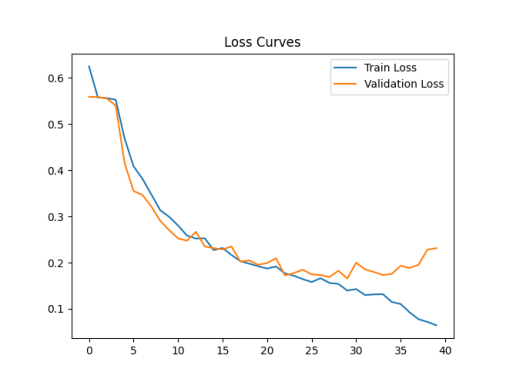

Test IoU : 0.4294938445612697
Test Dice : 0.4598517965928113


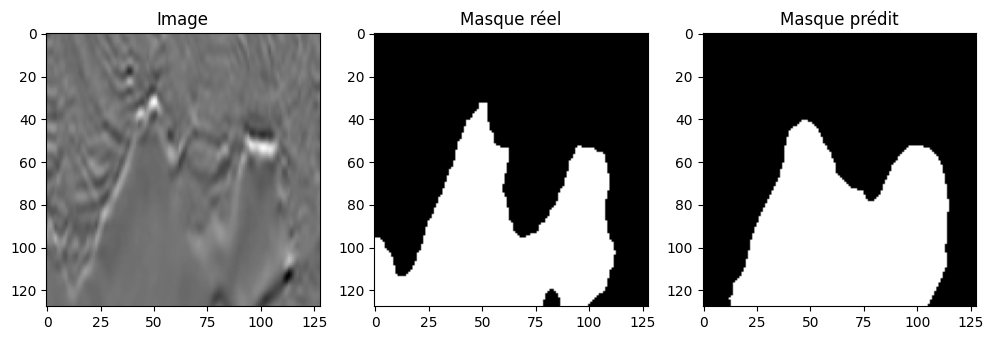

In [ ]:
# Entraînement du modèle en utilisant l'addition

model_add = UNet_Add().to(device)

try:
    model_add.load_state_dict(torch_load("modeles_entraines/model_add.pth"))
    print("Modèle importé")
    img = plt.imread("loss_model_add.png") 
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except FileNotFoundError:
    print("Fichier manquant")
    print("Lancement de l'entraînement...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_add.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    num_epochs = 1000
    train_losses = []
    val_losses_add = []
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model_add.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model_add(images)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model_add.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model_add(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses_add.append(val_loss)

        scheduler.step(val_loss)
        print("Epoch :", epoch+1, "| Train :", train_loss, "| Val :", val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model_add.state_dict(), "modeles_entraines/model_add.pth")
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= 10:
            print("Early stopping déclenché à l'époque :", epoch+1)
            break

    notebook_dir = os.getcwd()
    os.makedirs(os.path.join(notebook_dir, "figures"), exist_ok=True)

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses_add, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curves")
    plt.savefig("loss_model_add.png")
    plt.show()

model_add.load_state_dict(torch_load("modeles_entraines/model_add.pth"))
model_add.eval()

def compute_metrics(pred, mask):
    pred = pred.view(-1)
    mask = mask.view(-1)

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-8)

    return iou.item(), dice.item()

total_iou = 0
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model_add(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(images.size(0)):
            iou, dice = compute_metrics(preds[i], masks[i])
            total_iou += iou
            total_dice += dice

avg_iou = total_iou / len(test_dataset)
avg_dice = total_dice / len(test_dataset)

print("Test IoU :", avg_iou)
print("Test Dice :", avg_dice)

image, mask = test_dataset[0]

model_add.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model_add(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.permute(1,2,0).numpy()

image, mask = test_dataset[250]

model_add.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model_add(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image, cmap="grey")

plt.subplot(1,3,2)
plt.title("Masque réel")
plt.imshow(mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Masque prédit")
plt.imshow(pred, cmap="gray")

plt.show()

In [31]:
plt.plot(val_losses_base, label="Concat (original)")
plt.plot(val_losses_add,label="Addition")
plt.plot(val_losses_noskip, label="Sans skip")
plt.legend()
plt.title("Comparaison des skip connections")
plt.show()

NameError: name 'val_losses_base' is not defined

### 5.3 FCN and Auto-encoder
The proposed architecture is an auto-encoder like architecture, i.e., composed of an encoder and a decoder. Is it necessary ? Is it possible that we make use of a fully convolutional neural network (FCN) consisting of series of convolutions from the input to the output while keeping the image size, i.e., width and height, during all the convolutions ?


La différence entre les architectures FCN et Auto-encoder est que le FCN (Fully Connected Network) conserve la résolution constante dans toutes les couches du réseau. Avec l'Auto-encoder, on compresse spatialement l'information, ce qui permet à la couche de convolution de mieux comprendre le contexte global. Cela fonctionne sur des images simples, mais les performances se dégradent dès lors que l'on ajoute des détails complexes. De plus elle raisonne avec des oeillères ce qui rend sa comprehension du contexte global très limitée.

In [32]:
class FCN(nn.Module): # Définition d'un modèle FCN
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(

            nn.Conv2d(1, 16, 3, padding=1),   
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),  
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 32, 3, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),  
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), 
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 32, 3, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 3, padding=1),  
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 1, 1)               
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
# Entraînement du modèle en utilisant l'addition

model_fcn = FCN().to(device)

try :
    model_fcn.load_state_dict(torch_load("modeles_entraines/model_fcn.pth"))
    print("Modèle importé")
except FileNotFoundError:
    print("Pas de modèle enregistré")   

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_fcn.parameters(), lr=1e-3)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    num_epochs = 1000
    train_losses = []
    val_losses_fcn = []

    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):

        model_fcn.train()
        train_loss = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model_fcn(images)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model_fcn.eval()
        val_loss = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                outputs = model_fcn(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses_fcn.append(val_loss)

        scheduler.step(val_loss)

        print("Epoch :", epoch+1, "| Train :", train_loss, "| Val :", val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model_fcn.state_dict(), "modeles_entraines/model_fcn.pth")
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= 10:
            print("Early stopping triggered at epoch ", epoch)
            break

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses_fcn, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curves")
    plt.show()

Modèle importé


Entraînement beaucoup plus long (135 contre 40 dans les autres cas) et résultat bien moins bon

### 5.4 Threshold for inference
We have taken 0.5 as the threshold to decide whether to classify a pixel as salt or not. However, this choice proves not to be the optimal in terms of precision and recall rate for pixels being classified salt. Could you explain how we should define the precision and recall rate in our business case. Could you propose a strategy to improve both precision and recall ?

Le problème du choix de ce seuil arbitraire est que dans la réalité, il sera rarement à 0,5. Pour cela, on peut utiliser d'autres méthodes pour déterminer si l'on est en présence de sel ou non. Choisir un seuil plus élevé permet d'obtenir des prédictions de sel très confiante, mais en perdant beaucoup d'informations, tandis qu'un seuil plus faible permet l'inverse. Le mieux est donc de changer de méthode pour déterminer ce seuil. 

On essaiera dans la suite d'appliquer la méthode ROC et AUC. La courbe ROC teste tous les seuils possibles de 0 à 1 et calcule les TPR (True Positive Rate) et FPR (False Positive Rate). L'AUC est l'aire sous la courbe du TPR en fonction du FPT. Un AUC de 1 décrit un modèle parfait, tandis qu'un AUD de 0,5 représente un modèle aléatoire.

Seuil optimal : 0.22038480639457703
TPR : 0.9235323721456433
FPR : 0.06315970927626983
AUC : 0.9819166252751488


C:\Users\marca\AppData\Local\Temp\ipykernel_16160\693905771.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\marca\Desktop\Pour_Marc\Ecole\Centrale_Lyon\Ecole\3A\S10\MSO\CV\BE3 - Semantic Segmentation\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


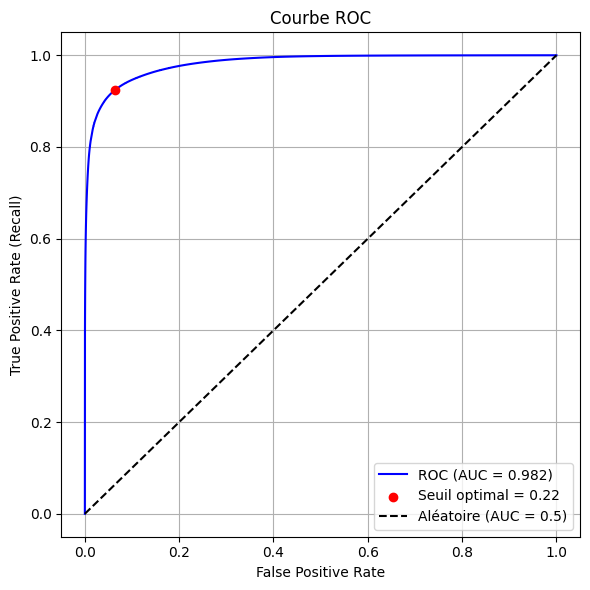

Comparaison seuil 0.5 vs seuil optimal :
Seuil = 0.5
Précision : 0.9317418206493869
Recall : 0.8544369145500987
F1-score : 0.8914165041237697
Seuil = 0.22038480639457703
Précision : 0.8282085186697713
Recall : 0.9235323106067873
F1-score : 0.8732768110004226


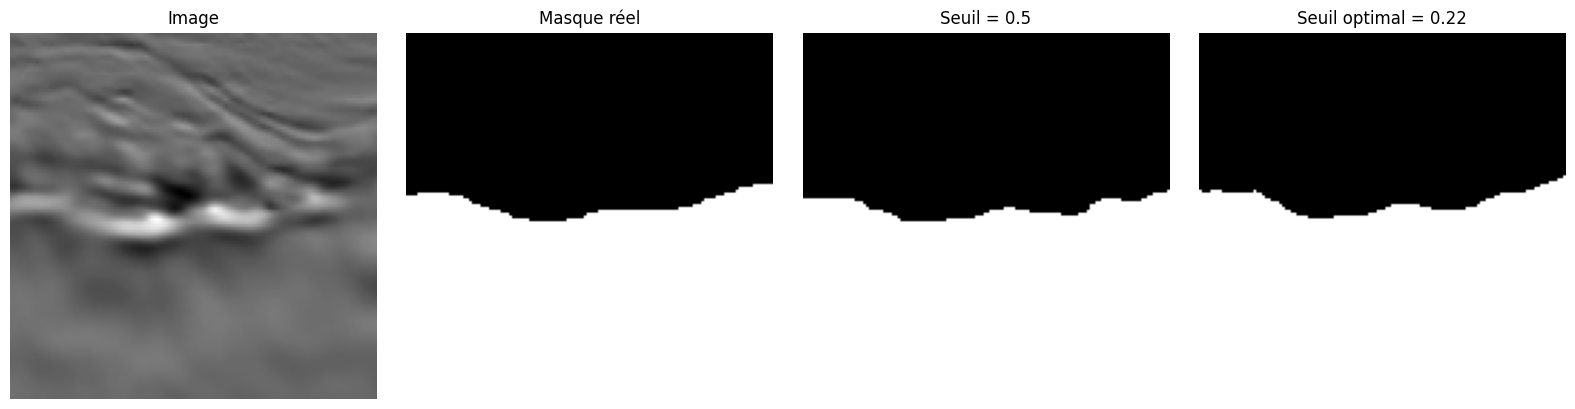

In [34]:
# Chargement du modèle (ici le modèle de base)

model.load_state_dict(torch_load("modeles_entraines/model_base.pth"))
model.eval()
all_preds = []
all_masks  = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        outputs = torch.sigmoid(model(images))        
        all_preds.append(outputs.cpu().numpy().flatten())
        all_masks.append(masks.cpu().numpy().flatten())

all_preds = np.concatenate(all_preds)   
all_masks  = np.concatenate(all_masks)  

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(all_masks, all_preds)
roc_auc = auc(fpr, tpr)

# Détermination du seuil optimal
distances = np.sqrt(fpr**2 + (1 - tpr)**2)
best_idx  = np.argmin(distances)
best_threshold = thresholds[best_idx]

print("Seuil optimal :", best_threshold)
print("TPR :", tpr[best_idx])
print("FPR :", fpr[best_idx])
print("AUC :", roc_auc)

# Tracé de la courbe ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC (AUC = {roc_auc:.3f})")
plt.scatter(fpr[best_idx], tpr[best_idx], 
            color='red', zorder=5,
            label=f"Seuil optimal = {best_threshold:.2f}")
plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparaision des seuils
print("Comparaison seuil 0.5 vs seuil optimal :")

for seuil in [0.5, best_threshold]:
    preds_bin = (all_preds > seuil).astype(float)
    
    TP = ((preds_bin == 1) & (all_masks == 1)).sum()
    FP = ((preds_bin == 1) & (all_masks == 0)).sum()
    FN = ((preds_bin == 0) & (all_masks == 1)).sum()
    
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    
    print("Seuil =", seuil)
    print("Précision :", precision)
    print("Recall :", recall)
    print("F1-score :", f1)

# Visualisation sur une image du dataset
image, mask = test_dataset[70]

model.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = torch.sigmoid(model(input_tensor)).squeeze().cpu().numpy()

pred_05  = (output > 0.5).astype(float)
pred_opt = (output > best_threshold).astype(float)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image.squeeze().numpy(), cmap="gray")
axes[0].set_title("Image")

axes[1].imshow(mask.squeeze().numpy(), cmap="gray")
axes[1].set_title("Masque réel")

axes[2].imshow(pred_05, cmap="gray")
axes[2].set_title("Seuil = 0.5")

axes[3].imshow(pred_opt, cmap="gray")
axes[3].set_title(f"Seuil optimal = {best_threshold:.2f}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()